<a href="https://www.kaggle.com/code/tuannm3823/multi-class-food-recognition?scriptVersionId=322261553" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Multi-Class Food Recognition

**Course:** 94691 Deep Learning  
**Assessment:** Assignment 2 - Convolutional Neural Networks

This notebook builds a Food-101 image classifier and compares transfer learning
against deeper fine-tuning. The workflow is designed for Kaggle execution: data
is read from Kaggle input mounts, checkpoints are written to `/kaggle/working`,
and the committed notebook remains lightweight with outputs cleared.


## 1. Project Summary

Food-101 is a fine-grained visual categorization dataset containing 101 balanced
food classes. The classification problem is challenging because food images have
high presentation variance, inconsistent lighting, and strong visual overlap
between some categories.

The experiment has two stages:

| Stage | Purpose |
| --- | --- |
| Part A: Transfer learning | Freeze ImageNet-pretrained backbones and train a 3-layer classifier head for GoogLeNet, ResNet50, and MobileNetV3 Large. |
| Part B: Fine-tuning | Select the strongest Part A model and unfreeze deeper ResNet50 blocks to adapt visual features to Food-101. |

The target metric is top-1 validation accuracy, with per-class F1 used for error
analysis.


## 2. Runtime, Imports, And Configuration

All libraries are imported once in this section. Configuration values are kept in
`CFG` so the notebook can switch between full training and checkpoint-based
inference without editing downstream cells.


In [1]:
import random
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.10.0+cu128


In [2]:
@dataclass(frozen=True)
class CFG:
    """Central notebook configuration."""

    MODE: str = "train"  # Options: "train" or "inference"
    SEED: int = 42
    BATCH_SIZE: int = 32
    IMAGE_SIZE: tuple[int, int] = (224, 224)
    NUM_CLASSES: int = 101
    NUM_WORKERS: int = 2
    LEARNING_RATE: float = 1e-3
    FINE_TUNE_LEARNING_RATE: float = 1e-5
    TRANSFER_EPOCHS: int = 5
    FINE_TUNE_EPOCHS: int = 5
    SELECTED_ARCHITECTURE: str = "ResNet50"
    SELECTED_FINETUNE_EXPERIMENT: str = "Exp_2_Layer3_4"
    LOCAL_ROOT: Path = Path("/kaggle/working")
    RESULTS_DIR: Path = Path("/kaggle/working/results")
    DATA_DIR: Path = Path("/kaggle/input/datasets/kmader/food41")


assert CFG.MODE in {"train", "inference"}, "CFG.MODE must be 'train' or 'inference'."
CFG.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Execution device: GPU ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Execution device: Apple Silicon MPS")
else:
    device = torch.device("cpu")
    print("Execution device: CPU")

print(f"Notebook mode: {CFG.MODE}")

Execution device: GPU (Tesla T4)
Notebook mode: train


## 3. Data Ingestion And Audit

The Food-101 Kaggle dataset is expected to contain an `images/` directory where
each class has its own folder. The manifest converts that folder structure into
a DataFrame with image paths and labels, which makes stratified splitting and
EDA straightforward.


In [3]:
def create_data_manifest(image_dir: Path) -> pd.DataFrame:
    """Create an image-path and label manifest from class folders.

    Args:
        image_dir: Directory containing one subdirectory per class.

    Returns:
        DataFrame with `path` and `label` columns.
    """
    records: list[dict[str, str]] = []
    class_dirs = sorted(path for path in image_dir.iterdir() if path.is_dir())
    for class_dir in class_dirs:
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                records.append({"path": str(image_path), "label": class_dir.name})

    return pd.DataFrame.from_records(records)


DATA_DIR = CFG.DATA_DIR
IMAGE_DIR = DATA_DIR / "images"
if not IMAGE_DIR.exists():
    raise FileNotFoundError(
        "Food-101 images were not found at the configured Kaggle path: "
        f"{IMAGE_DIR}"
    )

df = create_data_manifest(IMAGE_DIR)

print(f"Food-101 root: {DATA_DIR}")
print(f"Image directory: {IMAGE_DIR}")
print(f"Total samples: {len(df):,}")
print(f"Total classes: {df['label'].nunique():,}")

Food-101 root: /kaggle/input/datasets/kmader/food41
Image directory: /kaggle/input/datasets/kmader/food41/images
Total samples: 101,000
Total classes: 101


       class_name  image_count
        apple_pie         1000
   baby_back_ribs         1000
          baklava         1000
   beef_carpaccio         1000
     beef_tartare         1000
       beet_salad         1000
         beignets         1000
         bibimbap         1000
    bread_pudding         1000
breakfast_burrito         1000

Class count summary:
count     101.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0


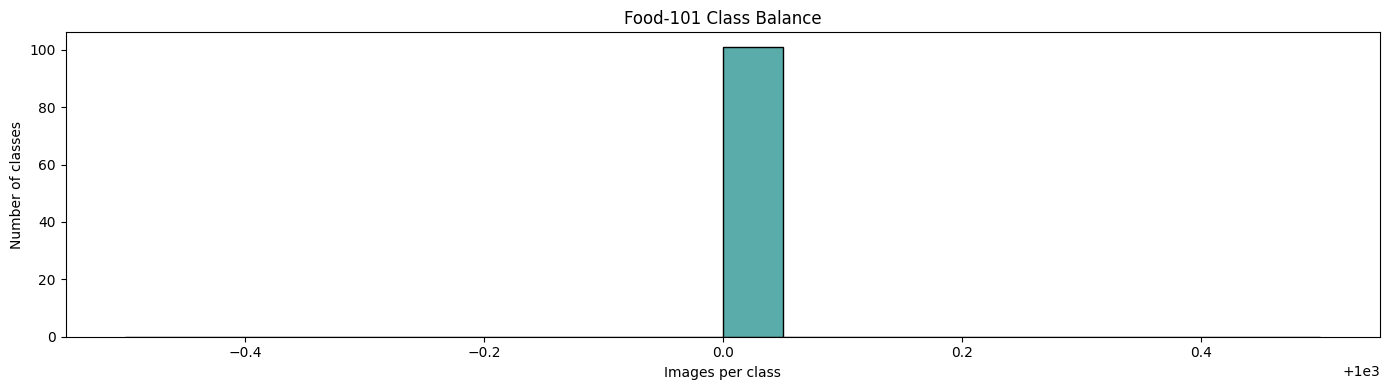

In [4]:
label_counts = df["label"].value_counts().sort_index()
class_summary = pd.DataFrame(
    {
        "class_name": label_counts.index,
        "image_count": label_counts.values,
    }
)

print(class_summary.head(10).to_string(index=False))
print("\nClass count summary:")
print(label_counts.describe().round(2).to_string())

plt.figure(figsize=(14, 4))
sns.histplot(label_counts.values, bins=20, color=sns.color_palette("viridis", 3)[1])
plt.title("Food-101 Class Balance")
plt.xlabel("Images per class")
plt.ylabel("Number of classes")
plt.tight_layout()
plt.show()


In [5]:
def sample_image_shapes(manifest: pd.DataFrame, sample_size: int = 500) -> pd.DataFrame:
    """Inspect image dimensions for a reproducible sample.

    Args:
        manifest: DataFrame with a `path` column.
        sample_size: Maximum number of images to inspect.

    Returns:
        DataFrame with sampled image widths and heights.
    """
    sample = manifest.sample(
        n=min(sample_size, len(manifest)),
        random_state=CFG.SEED,
    )
    shapes = []
    for image_path in sample["path"]:
        with Image.open(image_path) as image:
            shapes.append(image.size)

    return pd.DataFrame(shapes, columns=["width", "height"])


shape_df = sample_image_shapes(df)
print(shape_df.describe().loc[["min", "mean", "max"]].round(1).to_string())


      width  height
min   288.0   287.0
mean  495.0   479.9
max   512.0   512.0


## 4. Preprocessing, Splits, And Dataloaders

Training images receive light geometric augmentation. Validation, test, and
inference images use deterministic resizing and ImageNet normalization so model
comparisons remain consistent.


In [6]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

TRAIN_TRANSFORMS = transforms.Compose(
    [
        transforms.Resize(CFG.IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]
)

VAL_TRANSFORMS = transforms.Compose(
    [
        transforms.Resize(CFG.IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]
)

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=CFG.SEED,
    stratify=df["label"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=CFG.SEED,
    stratify=temp_df["label"],
)

print(f"Train samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Test samples: {len(test_df):,}")


Train samples: 80,800
Validation samples: 10,100
Test samples: 10,100


In [7]:
class FoodDataset(Dataset):
    """PyTorch dataset for Food-101 image classification."""

    def __init__(
        self,
        dataframe: pd.DataFrame,
        class_to_idx: dict[str, int],
        transform: transforms.Compose | None = None,
    ) -> None:
        """Initialize the dataset.

        Args:
            dataframe: Manifest with `path` and `label` columns.
            class_to_idx: Mapping from class name to numeric class index.
            transform: Optional torchvision transform pipeline.
        """
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.classes = [name for name, _ in sorted(class_to_idx.items(), key=lambda item: item[1])]
        self.transform = transform

    def __len__(self) -> int:
        """Return the number of samples."""
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        """Load one transformed image and class index."""
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return image, self.class_to_idx[row["label"]]


class_names = sorted(df["label"].unique())
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

train_dataset = FoodDataset(train_df, class_to_idx, transform=TRAIN_TRANSFORMS)
val_dataset = FoodDataset(val_df, class_to_idx, transform=VAL_TRANSFORMS)
test_dataset = FoodDataset(test_df, class_to_idx, transform=VAL_TRANSFORMS)

pin_memory = device.type == "cuda"
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=pin_memory,
)

batch_images, batch_labels = next(iter(train_loader))
print(f"Batch image shape: {tuple(batch_images.shape)}")
print(f"Batch label shape: {tuple(batch_labels.shape)}")


Batch image shape: (32, 3, 224, 224)
Batch label shape: (32,)


## 5. Model Construction

Each transfer-learning model uses ImageNet-pretrained features and the same
3-layer classifier head. This keeps the comparison focused on the backbone
rather than on differences in classifier capacity.


In [8]:
def make_classifier_head(in_features: int, num_classes: int) -> nn.Sequential:
    """Build the assignment-required 3-layer classifier head."""
    return nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes),
    )


def freeze_parameters(model: nn.Module) -> None:
    """Freeze all model parameters in place."""
    for parameter in model.parameters():
        parameter.requires_grad = False


def build_googlenet(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Create GoogLeNet with a custom Food-101 classifier."""
    weights = models.GoogLeNet_Weights.DEFAULT if pretrained else None
    model = models.googlenet(weights=weights)
    freeze_parameters(model)
    model.fc = make_classifier_head(model.fc.in_features, num_classes)
    return model


def build_resnet50(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Create ResNet50 with a custom Food-101 classifier."""
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    freeze_parameters(model)
    model.fc = make_classifier_head(model.fc.in_features, num_classes)
    return model


def build_mobilenet_v3(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Create MobileNetV3 Large with a custom Food-101 classifier."""
    weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
    model = models.mobilenet_v3_large(weights=weights)
    freeze_parameters(model)
    in_features = model.classifier[0].in_features
    model.classifier = make_classifier_head(in_features, num_classes)
    return model


def count_parameters(model: nn.Module) -> dict[str, int]:
    """Return total and trainable parameter counts."""
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return {"total": total, "trainable": trainable}


def checkpoint_path(name: str) -> Path:
    """Return the standard checkpoint path for a model or experiment name."""
    return CFG.RESULTS_DIR / f"{name.lower()}.pth"

In [9]:
if CFG.MODE == "train":
    transfer_models = {
        "GoogLeNet": build_googlenet(CFG.NUM_CLASSES).to(device),
        "ResNet50": build_resnet50(CFG.NUM_CLASSES).to(device),
        "MobileNetV3": build_mobilenet_v3(CFG.NUM_CLASSES).to(device),
    }

    parameter_rows = []
    for model_name, model in transfer_models.items():
        counts = count_parameters(model)
        parameter_rows.append(
            {
                "architecture": model_name,
                "total_parameters": counts["total"],
                "trainable_parameters": counts["trainable"],
            }
        )

    parameter_df = pd.DataFrame(parameter_rows)
    display(parameter_df)

    dummy_batch = torch.randn(1, 3, *CFG.IMAGE_SIZE).to(device)
    for model_name, model in transfer_models.items():
        output = model(dummy_batch)
        print(f"{model_name}: output shape {tuple(output.shape)}")
else:
    transfer_models = {}
    print("Skipping transfer model initialization in inference mode.")


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 201MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 199MB/s]


,architecture,total_parameters,trainable_parameters
0,GoogLeNet,6281989,682085
1,ResNet50,24714405,1206373
2,MobileNetV3,3621269,649317


GoogLeNet: output shape (1, 101)
ResNet50: output shape (1, 101)
MobileNetV3: output shape (1, 101)


## 6. Training And Evaluation Utilities

The training loop is shared by both transfer learning and fine-tuning. It tracks
loss and accuracy per epoch and saves the checkpoint with the best validation
accuracy.


In [10]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    """Train one epoch and return average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100.0 * correct / total


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    """Evaluate a model and return average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100.0 * correct / total


def fit_model(
    model_name: str,
    model: nn.Module,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    save_path: Path,
) -> dict[str, list[float]]:
    """Train a model and save the best validation checkpoint."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -np.inf
    progress = tqdm(range(epochs), desc=model_name)

    for epoch in progress:
        start_time = time.time()
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        progress.set_postfix(
            {
                "train_acc": f"{train_acc:.1f}%",
                "val_acc": f"{val_acc:.1f}%",
                "val_loss": f"{val_loss:.3f}",
            }
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            elapsed = time.time() - start_time
            tqdm.write(
                f"Epoch {epoch + 1}: {model_name} improved to "
                f"{val_acc:.2f}% in {elapsed:.1f}s. Saved {save_path}."
            )

    return history


## 7. Part A: Transfer Learning Comparison

In training mode, this section trains the frozen-backbone baselines and records
validation performance for model selection. In inference mode, the section is
skipped because it is only needed to produce checkpoints.


In [11]:
criterion = nn.CrossEntropyLoss()

if CFG.MODE == "train":
    transfer_optimizers = {
        model_name: optim.Adam(
            (parameter for parameter in model.parameters() if parameter.requires_grad),
            lr=CFG.LEARNING_RATE,
        )
        for model_name, model in transfer_models.items()
    }

    transfer_history = {}
    for model_name, model in transfer_models.items():
        save_path = checkpoint_path(f"best_model_{model_name}")
        transfer_history[model_name] = fit_model(
            model_name=model_name,
            model=model,
            optimizer=transfer_optimizers[model_name],
            criterion=criterion,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=CFG.TRANSFER_EPOCHS,
            save_path=save_path,
        )
else:
    transfer_history = {}
    print("Skipping transfer learning comparison in inference mode.")


GoogLeNet:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1: GoogLeNet improved to 35.37% in 740.1s. Saved /kaggle/working/results/best_model_googlenet.pth.
Epoch 2: GoogLeNet improved to 38.64% in 310.5s. Saved /kaggle/working/results/best_model_googlenet.pth.
Epoch 3: GoogLeNet improved to 42.03% in 306.6s. Saved /kaggle/working/results/best_model_googlenet.pth.


ResNet50:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1: ResNet50 improved to 53.01% in 331.4s. Saved /kaggle/working/results/best_model_resnet50.pth.
Epoch 2: ResNet50 improved to 56.46% in 330.7s. Saved /kaggle/working/results/best_model_resnet50.pth.
Epoch 3: ResNet50 improved to 58.04% in 334.6s. Saved /kaggle/working/results/best_model_resnet50.pth.
Epoch 4: ResNet50 improved to 58.69% in 331.4s. Saved /kaggle/working/results/best_model_resnet50.pth.
Epoch 5: ResNet50 improved to 59.49% in 334.0s. Saved /kaggle/working/results/best_model_resnet50.pth.


MobileNetV3:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1: MobileNetV3 improved to 47.92% in 310.8s. Saved /kaggle/working/results/best_model_mobilenetv3.pth.
Epoch 2: MobileNetV3 improved to 51.66% in 299.6s. Saved /kaggle/working/results/best_model_mobilenetv3.pth.
Epoch 3: MobileNetV3 improved to 53.34% in 300.6s. Saved /kaggle/working/results/best_model_mobilenetv3.pth.
Epoch 5: MobileNetV3 improved to 54.60% in 289.3s. Saved /kaggle/working/results/best_model_mobilenetv3.pth.


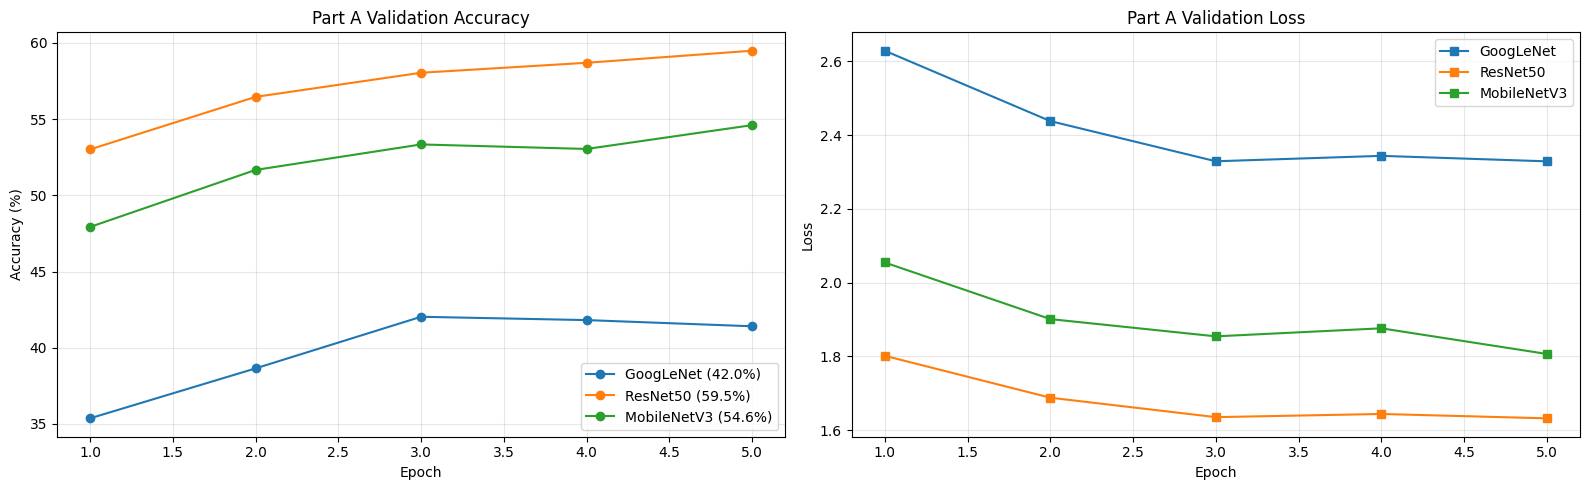

In [12]:
def plot_transfer_history(history: dict[str, dict[str, list[float]]]) -> None:
    """Plot validation accuracy and validation loss for transfer models."""
    if not history:
        print("No transfer history available to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for model_name, model_history in history.items():
        epochs = range(1, len(model_history["val_acc"]) + 1)
        best_acc = max(model_history["val_acc"])
        axes[0].plot(
            epochs,
            model_history["val_acc"],
            marker="o",
            label=f"{model_name} ({best_acc:.1f}%)",
        )
        axes[1].plot(
            epochs,
            model_history["val_loss"],
            marker="s",
            label=model_name,
        )

    axes[0].set_title("Part A Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Part A Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_transfer_history(transfer_history)


In [13]:
def classification_report_frame(
    model: nn.Module,
    loader: DataLoader,
    class_names: list[str],
) -> pd.DataFrame:
    """Return a per-class classification report for a model."""
    model.eval()
    predictions = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            predictions.extend(outputs.argmax(dim=1).cpu().numpy())
            labels_all.extend(labels.numpy())

    report = classification_report(
        labels_all,
        predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose().iloc[:-3].sort_values(
        "f1-score",
        ascending=False,
    )


if CFG.MODE == "train":
    selected_transfer_model = transfer_models[CFG.SELECTED_ARCHITECTURE]
    selected_checkpoint = checkpoint_path(f"best_model_{CFG.SELECTED_ARCHITECTURE}")
    selected_transfer_model.load_state_dict(
        torch.load(selected_checkpoint, map_location=device)
    )
    transfer_report_df = classification_report_frame(
        selected_transfer_model,
        val_loader,
        class_names,
    )

    print("Top 10 classes by F1 score:")
    display(transfer_report_df.head(10)[["precision", "recall", "f1-score"]])
    print("Bottom 10 classes by F1 score:")
    display(transfer_report_df.tail(10)[["precision", "recall", "f1-score"]])
else:
    transfer_report_df = pd.DataFrame()
    print("Skipping transfer-learning error analysis in inference mode.")


Top 10 classes by F1 score:


,precision,recall,f1-score
edamame,0.968421,0.92,0.943590
hot_and_sour_soup,0.868687,0.86,0.864322
miso_soup,0.860000,0.86,0.860000
oysters,0.882979,0.83,0.855670
pho,0.890110,0.81,0.848168
macarons,0.879121,0.80,0.837696
mussels,0.831683,0.84,0.835821
onion_rings,0.910256,0.71,0.797753
beignets,0.676471,0.92,0.779661
spaghetti_carbonara,0.847059,0.72,0.778378


Bottom 10 classes by F1 score:


,precision,recall,f1-score
ceviche,0.363636,0.40,0.380952
foie_gras,0.393258,0.35,0.370370
grilled_salmon,0.367347,0.36,0.363636
bread_pudding,0.436620,0.31,0.362573
pork_chop,0.410256,0.32,0.359551
huevos_rancheros,0.609756,0.25,0.354610
chocolate_mousse,0.327434,0.37,0.347418
cheesecake,0.258741,0.37,0.304527
tuna_tartare,0.261905,0.22,0.239130
filet_mignon,0.342857,0.12,0.177778


## 8. Part B: ResNet50 Fine-Tuning

ResNet50 is the selected fine-tuning candidate because it provides the strongest
transfer-learning accuracy in the saved assignment run. Two unfreezing depths
are compared:

| Experiment | Trainable layers |
| --- | --- |
| `Exp_1_Layer4` | ResNet `layer4` and classifier head |
| `Exp_2_Layer3_4` | ResNet `layer3`, `layer4`, and classifier head |


In [14]:
def set_resnet_trainable_layers(model: nn.Module, trainable_prefixes: tuple[str, ...]) -> None:
    """Freeze all parameters except the requested ResNet prefixes."""
    for name, parameter in model.named_parameters():
        parameter.requires_grad = name.startswith(trainable_prefixes)


def load_resnet_for_finetuning(
    checkpoint: Path,
    trainable_prefixes: tuple[str, ...],
) -> nn.Module:
    """Load the Part A ResNet50 checkpoint and configure trainable layers."""
    model = build_resnet50(CFG.NUM_CLASSES, pretrained=False)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    set_resnet_trainable_layers(model, trainable_prefixes)
    return model.to(device)


if CFG.MODE == "train":
    resnet_checkpoint = checkpoint_path("best_model_ResNet50")
    fine_tune_experiments = {
        "Exp_1_Layer4": load_resnet_for_finetuning(
            resnet_checkpoint,
            trainable_prefixes=("layer4", "fc"),
        ),
        "Exp_2_Layer3_4": load_resnet_for_finetuning(
            resnet_checkpoint,
            trainable_prefixes=("layer3", "layer4", "fc"),
        ),
    }

    fine_tune_rows = []
    for experiment_name, model in fine_tune_experiments.items():
        counts = count_parameters(model)
        fine_tune_rows.append(
            {
                "experiment": experiment_name,
                "trainable_parameters": counts["trainable"],
                "frozen_parameters": counts["total"] - counts["trainable"],
            }
        )
    display(pd.DataFrame(fine_tune_rows))
else:
    fine_tune_experiments = {}
    print("Skipping fine-tuning model setup in inference mode.")


,experiment,trainable_parameters,frozen_parameters
0,Exp_1_Layer4,16171109,8543296
1,Exp_2_Layer3_4,23269477,1444928


In [15]:
if CFG.MODE == "train":
    fine_tune_history = {}
    for experiment_name, model in fine_tune_experiments.items():
        optimizer = optim.Adam(
            (parameter for parameter in model.parameters() if parameter.requires_grad),
            lr=CFG.FINE_TUNE_LEARNING_RATE,
        )
        fine_tune_history[experiment_name] = fit_model(
            model_name=experiment_name,
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=CFG.FINE_TUNE_EPOCHS,
            save_path=checkpoint_path(f"finetuned_{experiment_name}"),
        )
else:
    fine_tune_history = {}
    print("Skipping fine-tuning loop in inference mode.")


Exp_1_Layer4:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1: Exp_1_Layer4 improved to 65.68% in 440.6s. Saved /kaggle/working/results/finetuned_exp_1_layer4.pth.
Epoch 2: Exp_1_Layer4 improved to 67.03% in 440.5s. Saved /kaggle/working/results/finetuned_exp_1_layer4.pth.
Epoch 3: Exp_1_Layer4 improved to 68.41% in 441.0s. Saved /kaggle/working/results/finetuned_exp_1_layer4.pth.
Epoch 4: Exp_1_Layer4 improved to 68.54% in 442.8s. Saved /kaggle/working/results/finetuned_exp_1_layer4.pth.
Epoch 5: Exp_1_Layer4 improved to 69.23% in 442.5s. Saved /kaggle/working/results/finetuned_exp_1_layer4.pth.


Exp_2_Layer3_4:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1: Exp_2_Layer3_4 improved to 68.10% in 631.6s. Saved /kaggle/working/results/finetuned_exp_2_layer3_4.pth.
Epoch 2: Exp_2_Layer3_4 improved to 70.40% in 626.4s. Saved /kaggle/working/results/finetuned_exp_2_layer3_4.pth.
Epoch 3: Exp_2_Layer3_4 improved to 71.70% in 627.3s. Saved /kaggle/working/results/finetuned_exp_2_layer3_4.pth.
Epoch 4: Exp_2_Layer3_4 improved to 72.24% in 628.1s. Saved /kaggle/working/results/finetuned_exp_2_layer3_4.pth.
Epoch 5: Exp_2_Layer3_4 improved to 72.86% in 634.2s. Saved /kaggle/working/results/finetuned_exp_2_layer3_4.pth.


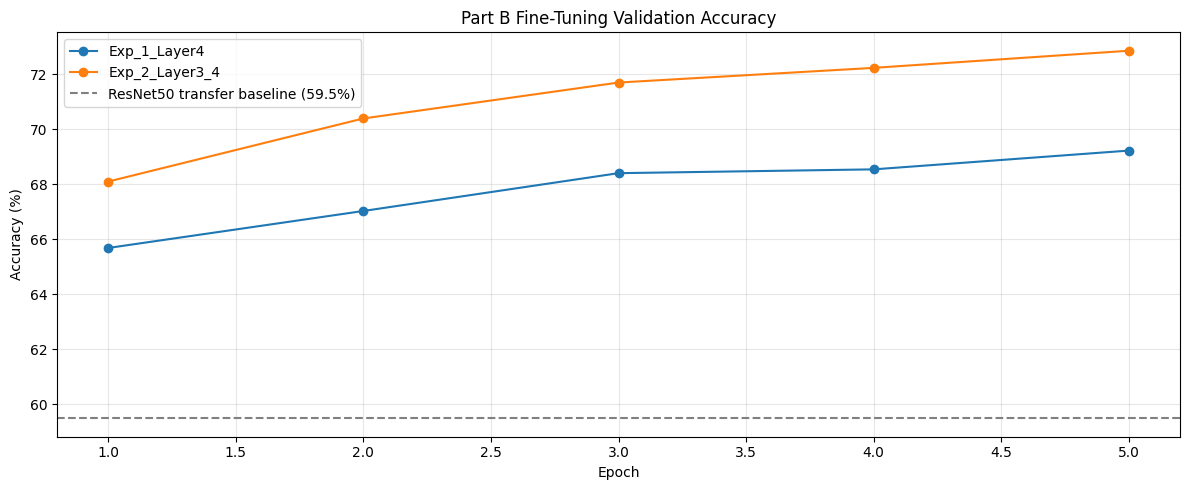

In [16]:
def plot_fine_tune_history(
    fine_tune_history: dict[str, dict[str, list[float]]],
    transfer_history: dict[str, dict[str, list[float]]],
) -> None:
    """Plot fine-tuning validation accuracy against the transfer baseline."""
    if not fine_tune_history:
        print("No fine-tuning history available to plot.")
        return

    plt.figure(figsize=(12, 5))
    for experiment_name, history in fine_tune_history.items():
        epochs = range(1, len(history["val_acc"]) + 1)
        plt.plot(epochs, history["val_acc"], marker="o", label=experiment_name)

    if CFG.SELECTED_ARCHITECTURE in transfer_history:
        baseline = max(transfer_history[CFG.SELECTED_ARCHITECTURE]["val_acc"])
        plt.axhline(
            baseline,
            color="gray",
            linestyle="--",
            label=f"{CFG.SELECTED_ARCHITECTURE} transfer baseline ({baseline:.1f}%)",
        )

    plt.title("Part B Fine-Tuning Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_fine_tune_history(fine_tune_history, transfer_history)


## 9. Final Model Evaluation And Inference

The final model uses the selected fine-tuned ResNet50 checkpoint. In training
mode, the notebook evaluates the selected checkpoint after fine-tuning. In
inference mode, this section can be run directly after attaching a checkpoint as
a Kaggle input or placing it in `/kaggle/working/results`.


In [17]:
def load_final_model(checkpoint: Path) -> nn.Module:
    """Load the selected fine-tuned ResNet50 checkpoint."""
    model = build_resnet50(CFG.NUM_CLASSES, pretrained=False)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    return model.to(device)


final_checkpoint = checkpoint_path(f"finetuned_{CFG.SELECTED_FINETUNE_EXPERIMENT}")
if final_checkpoint.exists():
    final_model = load_final_model(final_checkpoint)
    final_report_df = classification_report_frame(final_model, val_loader, class_names)

    print(f"Loaded final checkpoint: {final_checkpoint}")
    print("Top 10 classes by F1 score:")
    display(final_report_df.head(10)[["precision", "recall", "f1-score"]])
    print("Bottom 10 classes by F1 score:")
    display(final_report_df.tail(10)[["precision", "recall", "f1-score"]])
else:
    final_model = None
    final_report_df = pd.DataFrame()
    print(
        "Final checkpoint not found. Run with CFG.MODE = 'train' or attach "
        f"a checkpoint at {final_checkpoint}."
    )


Loaded final checkpoint: /kaggle/working/results/finetuned_exp_2_layer3_4.pth
Top 10 classes by F1 score:


,precision,recall,f1-score
edamame,0.959596,0.95,0.954774
hot_and_sour_soup,0.920792,0.93,0.925373
spaghetti_carbonara,0.900990,0.91,0.905473
macarons,0.909091,0.90,0.904523
seaweed_salad,0.909091,0.90,0.904523
oysters,0.916667,0.88,0.897959
miso_soup,0.875000,0.91,0.892157
pho,0.833333,0.95,0.887850
mussels,0.837838,0.93,0.881517
deviled_eggs,0.872549,0.89,0.881188


Bottom 10 classes by F1 score:


,precision,recall,f1-score
bread_pudding,0.525773,0.51,0.517766
ravioli,0.573171,0.47,0.516484
filet_mignon,0.509804,0.52,0.514851
chocolate_mousse,0.545455,0.48,0.510638
apple_pie,0.481818,0.53,0.504762
pork_chop,0.500000,0.49,0.494949
cheesecake,0.489130,0.45,0.468750
tuna_tartare,0.533333,0.40,0.457143
foie_gras,0.427273,0.47,0.447619
steak,0.521739,0.36,0.426036


Image: 3200621.jpg
True label: beef_tartare


,rank,label,probability
0,1,beef_tartare,0.946179
1,2,tuna_tartare,0.044417
2,3,foie_gras,0.003719


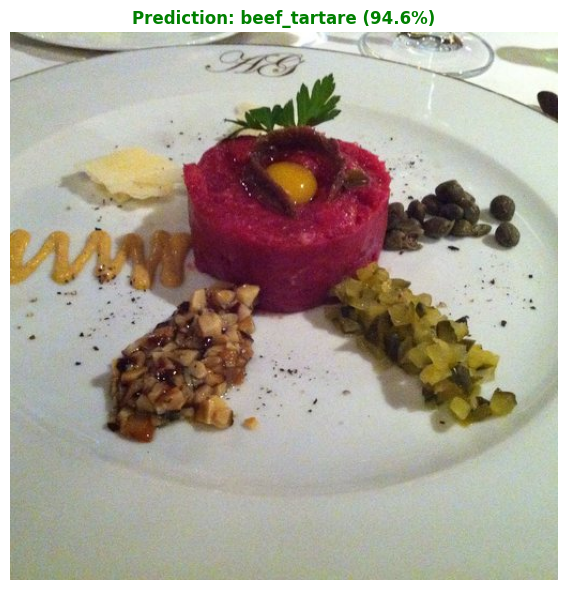

Image: 1808868.jpg
True label: peking_duck


,rank,label,probability
0,1,peking_duck,0.966343
1,2,chicken_wings,0.021266
2,3,baby_back_ribs,0.003703


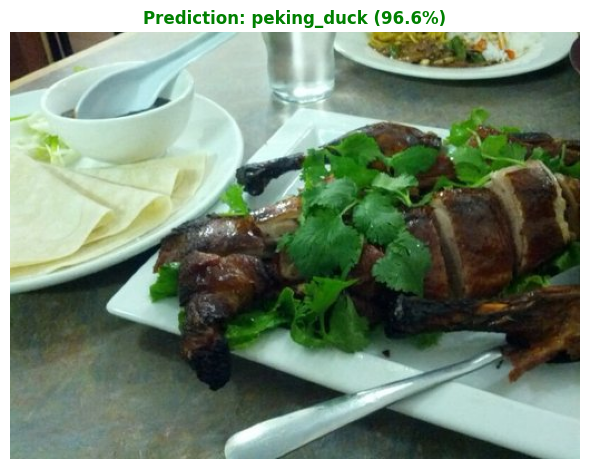

Image: 3123929.jpg
True label: prime_rib


,rank,label,probability
0,1,baby_back_ribs,0.338945
1,2,prime_rib,0.319649
2,3,steak,0.224191


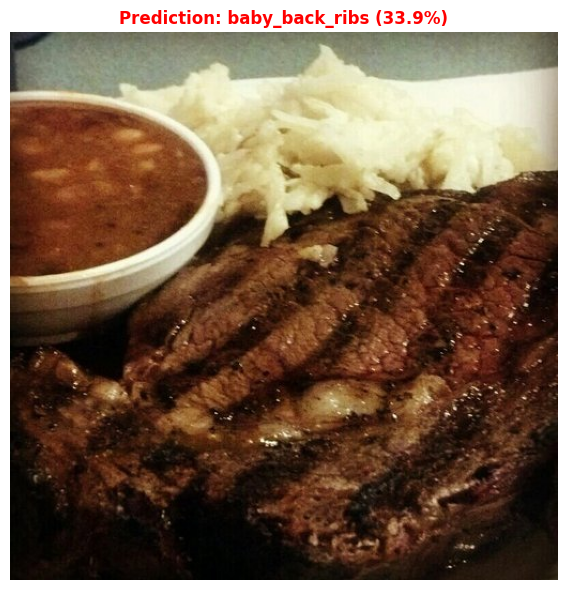

Image: 2324387.jpg
True label: fried_rice


,rank,label,probability
0,1,fried_rice,0.997751
1,2,risotto,0.001184
2,3,caesar_salad,0.000648


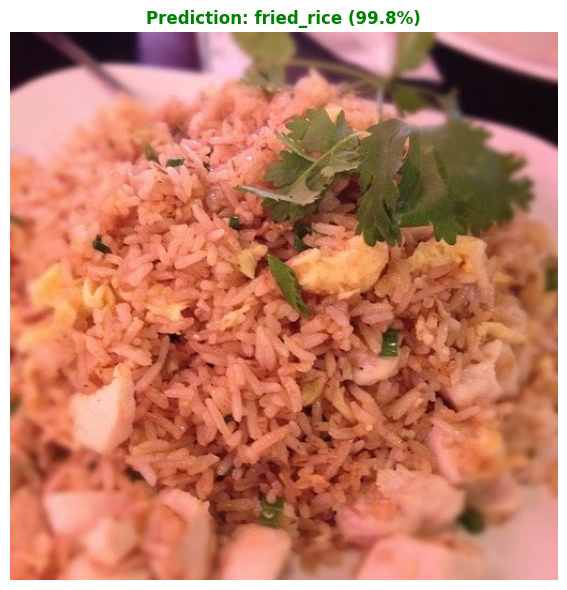

Image: 2986281.jpg
True label: ramen


,rank,label,probability
0,1,ramen,0.928358
1,2,huevos_rancheros,0.028165
2,3,shrimp_and_grits,0.021309


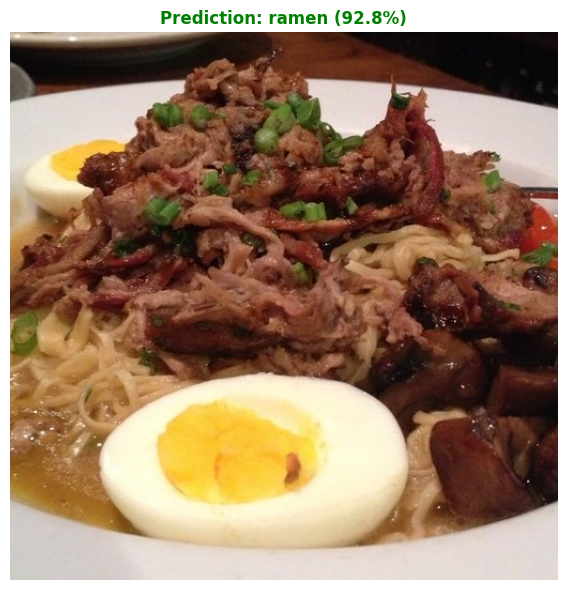

In [18]:
def predict_food(
    image_path: str | Path,
    model: nn.Module,
    class_names: list[str],
    top_k: int = 3,
) -> pd.DataFrame:
    """Predict the top food classes for one image.

    Args:
        image_path: Image file to classify.
        model: Trained Food-101 classifier.
        class_names: Class names ordered by model index.
        top_k: Number of predictions to return.

    Returns:
        DataFrame with predicted labels and probabilities.
    """
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")
    tensor = VAL_TRANSFORMS(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probabilities = F.softmax(model(tensor), dim=1).squeeze(0)

    top_probabilities, top_indices = torch.topk(probabilities, top_k)
    result = pd.DataFrame(
        {
            "rank": range(1, top_k + 1),
            "label": [class_names[idx] for idx in top_indices.cpu().numpy()],
            "probability": top_probabilities.cpu().numpy(),
        }
    )
    return result


def show_prediction(image_path: str | Path, model: nn.Module) -> None:
    """Display one image with its top-1 prediction and top-k table."""
    result = predict_food(image_path, model, class_names, top_k=3)
    true_label = Path(image_path).parent.name
    predicted_label = result.loc[0, "label"]
    title_color = "green" if predicted_label == true_label else "red"

    print(f"Image: {Path(image_path).name}")
    print(f"True label: {true_label}")
    display(result)

    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(
        f"Prediction: {predicted_label} ({result.loc[0, 'probability']:.1%})",
        color=title_color,
        fontweight="bold",
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if final_model is not None:
    class_dirs = [path for path in IMAGE_DIR.iterdir() if path.is_dir()]
    sampled_images = []
    for class_dir in random.sample(class_dirs, k=min(5, len(class_dirs))):
        candidates = [
            path
            for path in class_dir.iterdir()
            if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        if candidates:
            sampled_images.append(random.choice(candidates))

    for sampled_image in sampled_images:
        show_prediction(sampled_image, final_model)
else:
    print("Prediction examples skipped because final_model is not loaded.")
